# Import Libraries :-

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load Data :-

In [2]:
train = pd.read_csv("CSV Files/train.csv")
train.sample(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
483,484,1,3,"Turkula, Mrs. (Hedwig)",female,63.0,0,0,4134,9.5875,NaN,S
850,851,0,3,"Andersson, Master. Sigvard Harald Elias",male,4.0,4,2,347082,31.2750,NaN,S


In [3]:
test = pd.read_csv("CSV Files/test.csv")
test.sample(3)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
378,1270,1,"Hipkins, Mr. William Edward",male,55.0,0,0,680,50.0000,C39,S
297,1189,3,"Samaan, Mr. Hanna",male,NaN,2,0,2662,21.6792,NaN,C
196,1088,1,"Spedden, Master. Robert Douglas",male,6.0,0,2,16966,134.5000,E34,C


In [4]:
df = pd.concat([train,test], ignore_index = True)
df.sample(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
741,742,0.0,1,"Cavendish, Mr. Tyrell William",male,36.0,1,0,19877,78.850,C46,S
1211,1212,NaN,3,"Andersson, Mr. Johan Samuel",male,26.0,0,0,347075,7.775,NaN,S
562,563,0.0,2,"Norman, Mr. Robert Douglas",male,28.0,0,0,218629,13.500,NaN,S


# Data Overview :-

### (i) Shape & Info

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB


In [6]:
df.shape

(1309, 12)

### (ii) Description of Columns 

#### Column Description

| Column          | Description                                                                                                                              | Values / Type                                      |
| --------------- | ---------------------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------- |
| **PassengerId** | Unique identifier assigned to each passenger. It is used only for identification and has no predictive value.                            | Integer                                            |
| **Survived**    | Target variable indicating whether a passenger survived the disaster. Available only in the training set.                                | 0 = Did Not Survive, 1 = Survived                  |
| **Pclass**      | Passenger ticket class, representing socio-economic status.                                                                              | 1 = First Class, 2 = Second Class, 3 = Third Class |
| **Name**        | Full name of the passenger. Titles such as Mr., Mrs., Miss, and Master can be extracted for feature engineering.                         | Text                                               |
| **Sex**         | Gender of the passenger.                                                                                                                 | Male / Female                                      |
| **Age**         | Age of the passenger in years. Some values are missing.                                                                                  | Numeric                                            |
| **SibSp**       | Number of siblings and spouses traveling with the passenger aboard the Titanic.                                                          | Integer                                            |
| **Parch**       | Number of parents and children traveling with the passenger aboard the Titanic.                                                          | Integer                                            |
| **Ticket**      | Passenger ticket number. Contains both numeric and alphanumeric formats.                                                                 | Text                                               |
| **Fare**        | Amount paid for the passenger ticket.                                                                                                    | Numeric                                            |
| **Cabin**       | Cabin number assigned to the passenger. A large proportion of values are missing. The cabin deck can be extracted from the first letter. | Text                                               |
| **Embarked**    | Port where the passenger boarded the Titanic.                                                                                            | C = Cherbourg, Q = Queenstown, S = Southampton     |


### (iii) Missing Values 

In [7]:
df.isnull().mean()*100

PassengerId     0.000000
Survived       31.932773
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            20.091673
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.076394
Cabin          77.463713
Embarked        0.152788
dtype: float64

### (iv) Target Distribution 

In [8]:
print(train['Survived'].value_counts().rename({0:"Not Survived",1:"Survived"}))
survival_rate = train['Survived'].mean() * 100
print("\nOverall Survival Rate :", round(survival_rate, 1))

Not Survived    549
Survived        342
Name: Survived, dtype: int64

Overall Survival Rate : 38.4


### (v) Numeric Summary 

In [9]:
df.describe().round(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,1309.00,891.00,1309.00,1046.00,1309.00,1309.00,1308.00
mean,655.00,0.38,2.29,29.88,0.50,0.39,33.30
std,378.02,0.49,0.84,14.41,1.04,0.87,51.76
min,1.00,0.00,1.00,0.17,0.00,0.00,0.00
25%,328.00,0.00,2.00,21.00,0.00,0.00,7.90
50%,655.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,982.00,1.00,3.00,39.00,1.00,0.00,31.28
max,1309.00,1.00,3.00,80.00,8.00,9.00,512.33


### Data Overview â€” Conclusion

- The full dataset has **1309 rows and 12 columns** (891 train + 418 test).
- **Survived** is empty for about **32%** of rows. These are the 418 test passengers, so their value is missing on purpose. In the train data, only about **38%** of people survived.
- Four columns have missing values: **Cabin (~77%)**, **Age (~20%)**, **Embarked (2 rows)** and **Fare (1 row)**. Cabin and Age have the most missing data.
- **Age** is around **30 years** on average. **Fare** is uneven â€” most people paid a low fare (about 14.5), but the highest fare is **512.33**, which looks like an outlier.
- Most people travelled in **3rd class**, and most were travelling with **no family** (no siblings, spouse, parents or children).

**Takeaway:** The data has some problems â€” Cabin and Age have many missing values, Fare has very high outliers, and the survived column is uneven. We fix these in the cleaning step.

#  FEATURE ENGINEERING :-

1. Title
2. Familysize
3. IsAlone
4. FamilyType
5. AgeGroup
6. IndividualFare
7. Deck

### (i) Title 

In [10]:
df["Name"]

0                                 Braund, Mr. Owen Harris
1       Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                  Heikkinen, Miss. Laina
3            Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                                Allen, Mr. William Henry
                              ...                        
1304                                   Spector, Mr. Woolf
1305                         Oliva y Ocana, Dona. Fermina
1306                         Saether, Mr. Simon Sivertsen
1307                                  Ware, Mr. Frederick
1308                             Peter, Master. Michael J
Name: Name, Length: 1309, dtype: object

In [11]:
df["Title"] = df["Name"].str.split(',').str[1].str.split('.').str[0].str.strip()
df["Title"].value_counts()

Mr              757
Miss            260
Mrs             197
Master           61
Rev               8
Dr                8
Col               4
Mlle              2
Major             2
Ms                2
Lady              1
Sir               1
Mme               1
Don               1
Capt              1
the Countess      1
Jonkheer          1
Dona              1
Name: Title, dtype: int64

In [12]:
df["Title"] = df["Title"].replace({
    "Ms": "Miss",
    "Mlle": "Miss",
    "Mme": "Mrs"
})

In [13]:
df["Title"].value_counts()

Mr              757
Miss            264
Mrs             198
Master           61
Rev               8
Dr                8
Col               4
Major             2
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Dona              1
Name: Title, dtype: int64

### (ii) Familysize

In [14]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

### (iii) IsAlone

In [15]:
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

### (iv) FamilyType

In [16]:
df["FamilyType"] = np.where(df["FamilySize"]==1,"Alone",np.where(df["FamilySize"]<=4 , "Small","Large"))

### (v) AgeGroup

In [17]:
bins = [0, 12, 18, 35, 60, 200]
labels = ["Child", "Teen", "Adult", "Mid-age", "Senior"]
df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)

### (vi) IndividualFare

In [18]:
df["IndividualFare"] = df["Fare"] / df["FamilySize"]

### (vii) Deck

In [19]:
df["Deck"] = df["Cabin"].str[0] 
df["Deck"].value_counts()

C    94
B    65
D    46
E    41
A    22
F    21
G     5
T     1
Name: Deck, dtype: int64

### Feature Engineering â€” Conclusion

We made seven new columns to get useful information that the original columns do not show directly:

- **Title** â€” taken from the Name column (Mr, Miss, Mrs, Master, etc.), with rare titles grouped together. It gives a hint about a person's sex, age and status.
- **FamilySize** â€” `SibSp + Parch + 1`, the total number of family members on board.
- **IsAlone** â€” tells us if a person was travelling alone (FamilySize = 1).
- **FamilyType** â€” groups FamilySize into **Alone / Small (â‰¤4) / Large**.
- **AgeGroup** â€” splits Age into **Child, Teen, Adult, Mid-age and Senior**.
- **IndividualFare** â€” `Fare / FamilySize`, because the Fare value is for the whole group, not one person.
- **Deck** â€” the first letter of the Cabin number. We can use it after filling the missing cabins.

**Takeaway:** These new columns turn the raw data into more useful information (family size, status, fare per person) and help in the next analysis and model steps.

# Data Analysis :-

1. Univariate Analysis
2. Bivariate Analysis
3. Multivariate Analysis

## (i) Univariate Analysis

### (a) Passenger ID

In [20]:
print("PassengerId\n")

print("Total Rows          :", len(df))
print("Null Values         :", df["PassengerId"].isnull().sum())
print("Unique Values       :", df["PassengerId"].nunique())
print("Duplicate Values    :", df["PassengerId"].duplicated().sum())
print("Minimum ID          :", df["PassengerId"].min())
print("Maximum ID          :", df["PassengerId"].max())

PassengerId

Total Rows          : 1309
Null Values         : 0
Unique Values       : 1309
Duplicate Values    : 0
Minimum ID          : 1
Maximum ID          : 1309


### (b) Survived 

Survived

Total Rows          : 1309
Null Values         : 418
Unique Values       : 2

Passenger Status
Not Survived (0)    : 549
Survived (1)        : 342


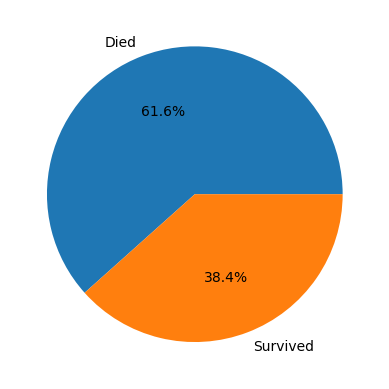

In [21]:
print("Survived\n")
print("Total Rows          :", len(df))
print("Null Values         :", df["Survived"].isnull().sum())
print("Unique Values       :", df["Survived"].nunique())

print("\nPassenger Status")
print("Not Survived (0)    :", df["Survived"].value_counts()[0])
print("Survived (1)        :", df["Survived"].value_counts()[1])

df['Survived'].value_counts().plot(kind='pie',autopct='%1.1f%%',labels=['Died', 'Survived'])
plt.ylabel('')
plt.show()

### (c) Pclass

Pclass

Total Rows    : 1309
Null Values   : 0
Unique Values : 3

Frequency Count

3    709
1    323
2    277
Name: Pclass, dtype: int64




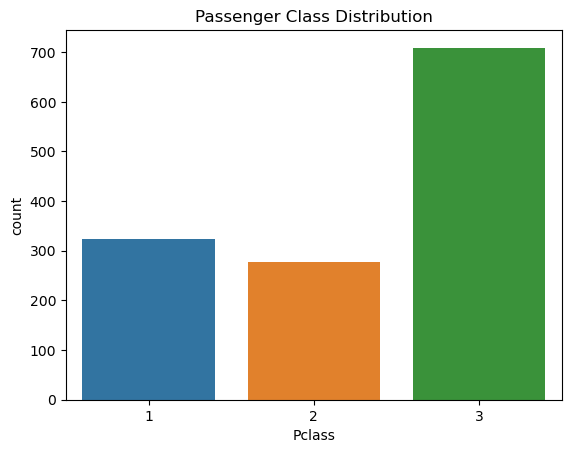

In [22]:
print("Pclass\n")
print("Total Rows    :", len(df))
print("Null Values   :", df["Pclass"].isnull().sum())
print("Unique Values :", df["Pclass"].nunique())
print("")

print("Frequency Count\n")
print(df["Pclass"].value_counts())
print("")

print("")
sns.countplot(data=df, x="Pclass")
plt.title("Passenger Class Distribution")
plt.show()

### (d) Name

In [23]:
print("Name\n")
print("Total Rows      :", len(df))
print("Null Values     :", df["Name"].isnull().sum())
print("Unique Values   :", df["Name"].nunique())
print("Duplicate Names :", df["Name"].duplicated().sum())

Name

Total Rows      : 1309
Null Values     : 0
Unique Values   : 1307
Duplicate Names : 2


### (e) Sex

Sex

Total Rows    : 1309
Null Values   : 0
Unique Values : 2

Frequency Count

male      843
female    466
Name: Sex, dtype: int64


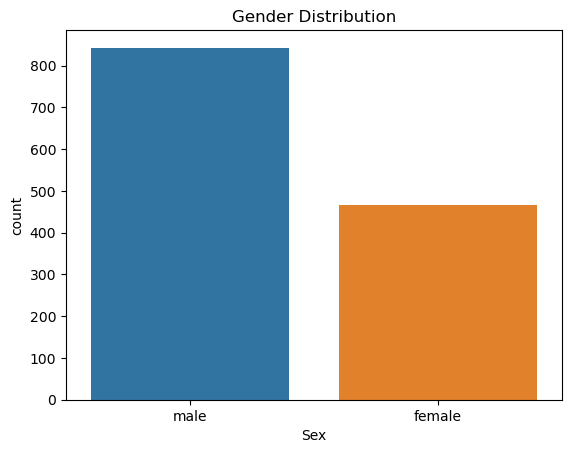

In [24]:
print("Sex\n")
print("Total Rows    :", len(df))
print("Null Values   :", df["Sex"].isnull().sum())
print("Unique Values :", df["Sex"].nunique())
print("")

print("Frequency Count\n")
print(df["Sex"].value_counts())

sns.countplot(data=df, x="Sex")
plt.title("Gender Distribution")
plt.show()

### (f) Age

Age

Total Rows    : 1309
Null Values   : 263
Unique Values : 98
Minimum Age : 0.17
Maximum Age : 80.0
Mean Age    : 29.88
Median Age  : 28.0
Std Dev     : 14.41


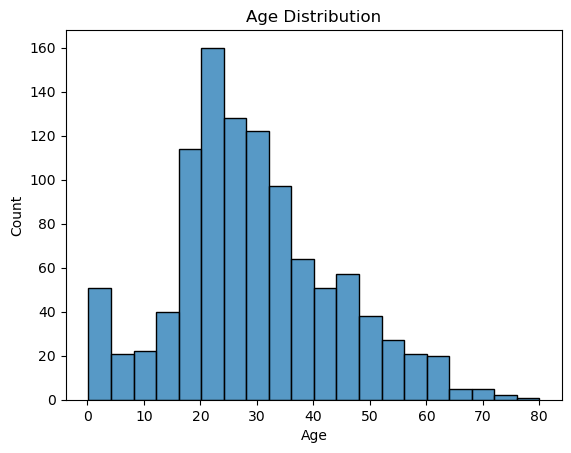

In [25]:
print("Age\n")
print("Total Rows    :", len(df))
print("Null Values   :", df["Age"].isnull().sum())
print("Unique Values :", df["Age"].nunique())
print("Minimum Age :", df["Age"].min())
print("Maximum Age :", df["Age"].max())
print("Mean Age    :", round(df["Age"].mean(), 2))
print("Median Age  :", df["Age"].median())
print("Std Dev     :", round(df["Age"].std(), 2))

sns.histplot(df["Age"], bins=20)
plt.title("Age Distribution")
plt.show()

### (g) SibSp

SibSp

Total Rows    : 1309
Null Values   : 0
Unique Values : 7
Min    : 0
Max    : 8
Mean   : 0.5
Median : 0.0

Frequency Count

0    891
1    319
2     42
3     20
4     22
5      6
8      9
Name: SibSp, dtype: int64


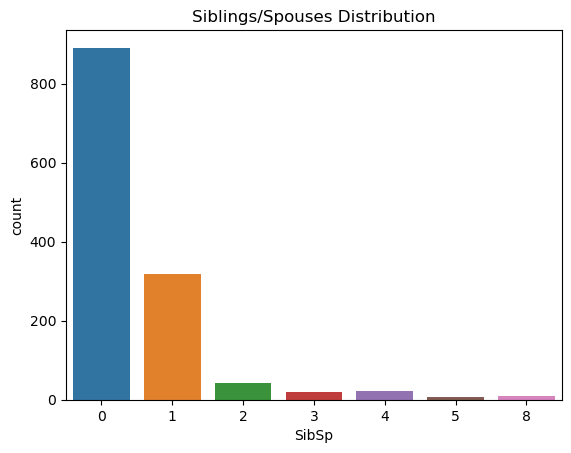

In [26]:
print("SibSp\n")
print("Total Rows    :", len(df))
print("Null Values   :", df["SibSp"].isnull().sum())
print("Unique Values :", df["SibSp"].nunique())

print("Min    :", df["SibSp"].min())
print("Max    :", df["SibSp"].max())
print("Mean   :", round(df["SibSp"].mean(), 2))
print("Median :", df["SibSp"].median())
print("")

print("Frequency Count\n")
print(df["SibSp"].value_counts().sort_index())

sns.countplot(data=df, x="SibSp")
plt.title("Siblings/Spouses Distribution")
plt.show()

### (h) Parch

Parch

Null Values : 0
Unique Values : 8

Frequency Count

0    1002
1     170
2     113
3       8
4       6
5       6
6       2
9       2
Name: Parch, dtype: int64


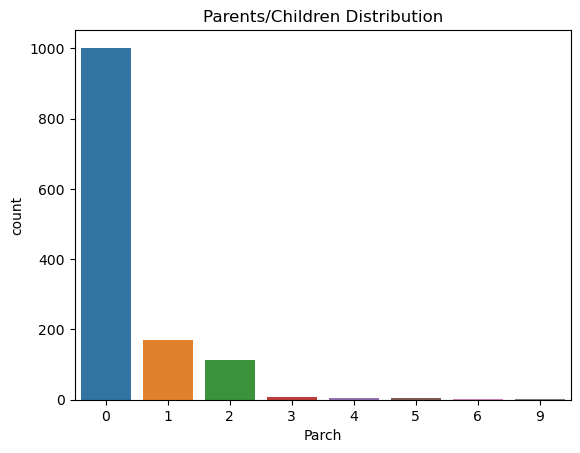

In [27]:
print("Parch\n")
print("Null Values :", df["Parch"].isnull().sum())
print("Unique Values :", df["Parch"].nunique())
print("")

print("Frequency Count\n")
print(df["Parch"].value_counts().sort_index())

sns.countplot(data=df, x="Parch")
plt.title("Parents/Children Distribution")
plt.show()

### (i) Ticket

In [28]:
print("Ticket\n")
print("Total Rows    :", len(df))
print("Null Values :", df["Ticket"].isnull().sum())
print("Unique Values :", df["Ticket"].nunique())
print("Duplicate Tickets :", df["Ticket"].duplicated().sum())

Ticket

Total Rows    : 1309
Null Values : 0
Unique Values : 929
Duplicate Tickets : 380


### (j) Fare

Fare

count    1308.000000
mean       33.295479
std        51.758668
min         0.000000
25%         7.895800
50%        14.454200
75%        31.275000
max       512.329200
Name: Fare, dtype: float64


<AxesSubplot:xlabel='Fare'>

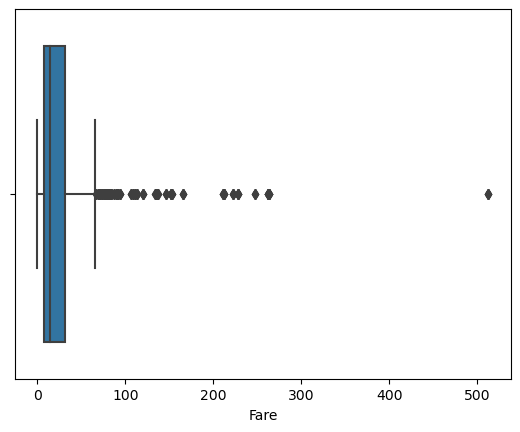

In [29]:
print("Fare\n")
print(df["Fare"].describe())

sns.boxplot(x=df["Fare"])

### (k) Cabin

In [30]:
print("Cabin\n")
print("Total Rows    :", len(df))
print("Null Values   :", df["Cabin"].isnull().sum())
print("Unique Values :", df["Cabin"].nunique())
print("Missing Percentage :",round(df["Cabin"].isnull().mean() * 100, 2),"%")

Cabin

Total Rows    : 1309
Null Values   : 1014
Unique Values : 186
Missing Percentage : 77.46 %


### (l) Embarked

Embarked

Total Rows    : 1309
Null Values   : 2
Unique Values : 3

Frequency Count

S    914
C    270
Q    123
Name: Embarked, dtype: int64


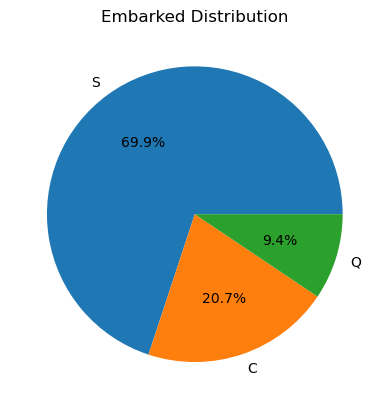

In [31]:
print("Embarked\n")
print("Total Rows    :", len(df))
print("Null Values   :", df["Embarked"].isnull().sum())
print("Unique Values :", df["Embarked"].nunique())
print("")
print("Frequency Count\n")
print(df["Embarked"].value_counts())
df["Embarked"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.ylabel("")
plt.title("Embarked Distribution")
plt.show()

### (m) Title

Title

Total Rows    : 1309
Null Values   : 0
Unique Values : 15

Frequency Count

Mr              757
Miss            264
Mrs             198
Master           61
Rev               8
Dr                8
Col               4
Major             2
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Dona              1
Name: Title, dtype: int64


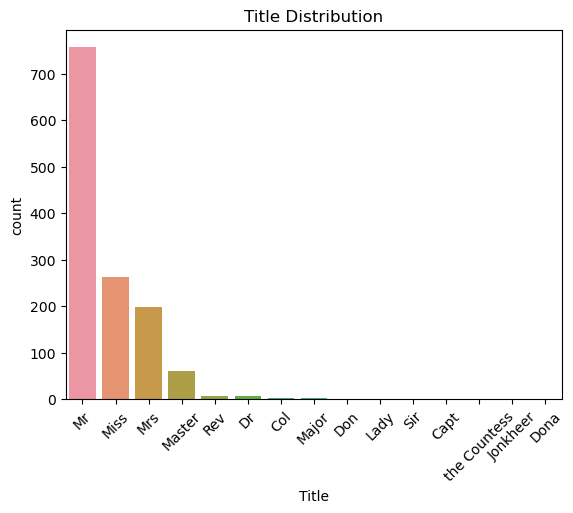

In [32]:
print("Title\n")
print("Total Rows    :", len(df))
print("Null Values   :", df["Title"].isnull().sum())
print("Unique Values :", df["Title"].nunique())

print("\nFrequency Count\n")
print(df["Title"].value_counts())

sns.countplot(data=df, x="Title",order=df["Title"].value_counts().index)

plt.xticks(rotation=45)
plt.title("Title Distribution")
plt.show()

### (n) FamilySize

FamilySize

Null Values   : 0
Unique Values : 9
count    1309.000000
mean        1.883881
std         1.583639
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        11.000000
Name: FamilySize, dtype: float64
1     790
2     235
3     159
4      43
5      22
6      25
7      16
8       8
11     11
Name: FamilySize, dtype: int64


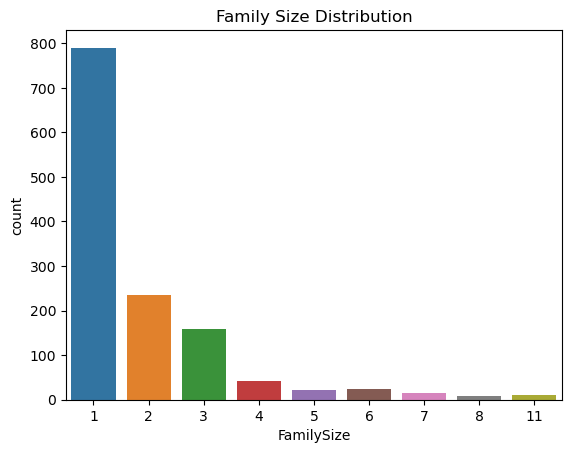

In [33]:
print("FamilySize\n")
print("Null Values   :", df["FamilySize"].isnull().sum())
print("Unique Values :", df["FamilySize"].nunique())
print(df["FamilySize"].describe())
print(df["FamilySize"].value_counts().sort_index())
sns.countplot(data=df, x="FamilySize")
plt.title("Family Size Distribution")
plt.show()

### (o) IsAlone

IsAlone

Null Values   : 0
Unique Values : 2
1    790
0    519
Name: IsAlone, dtype: int64


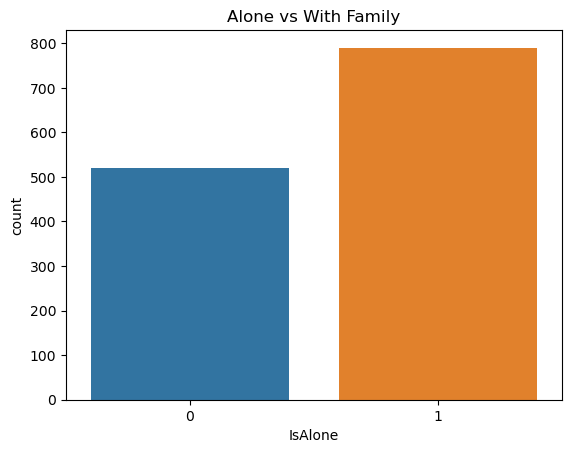

In [34]:
print("IsAlone\n")
print("Null Values   :", df["IsAlone"].isnull().sum())
print("Unique Values :", df["IsAlone"].nunique())
print(df["IsAlone"].value_counts())
sns.countplot(data=df, x="IsAlone")
plt.title("Alone vs With Family")
plt.show()

### (p) FamilyType

FamilyType

Null Values   : 0
Unique Values : 3
Alone    790
Small    437
Large     82
Name: FamilyType, dtype: int64


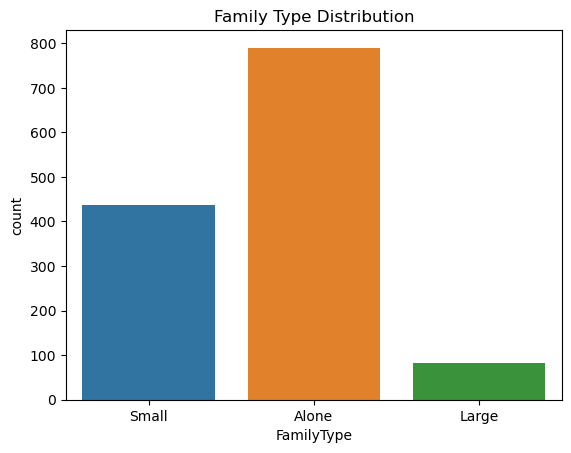

In [35]:
print("FamilyType\n")
print("Null Values   :", df["FamilyType"].isnull().sum())
print("Unique Values :", df["FamilyType"].nunique())

print(df["FamilyType"].value_counts())
sns.countplot(data=df,x="FamilyType")

plt.title("Family Type Distribution")
plt.show()

### (q) AgeGroup

AgeGroup

Null Values   : 263
Unique Values : 5
Adult      531
Mid-age    289
Teen        99
Child       94
Senior      33
Name: AgeGroup, dtype: int64


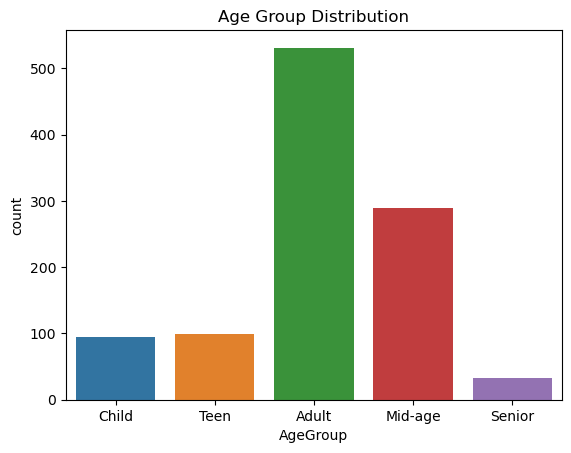

In [36]:
print("AgeGroup\n")
print("Null Values   :", df["AgeGroup"].isnull().sum())
print("Unique Values :", df["AgeGroup"].nunique())
print(df["AgeGroup"].value_counts())
sns.countplot(data=df,x="AgeGroup")

plt.title("Age Group Distribution")
plt.show()

### Univariate Analysis â€“ Conclusion

Univariate analysis means looking at one column at a time to understand it better.

* **Survived:** Only about **38% of people survived**. Most people did not survive.
* **Pclass:** Most people travelled in **Third Class**. First Class had the fewest people.
* **Sex:** There were more men than women â€” about **65% men** and **35% women**.
* **Age:** Most people were **young adults, between 20 and 35 years old**. About **20% of the age values are missing**.
* **SibSp and Parch:** Most people travelled with **no siblings, spouse, parents or children**, so many were travelling alone.
* **Fare:** Most people paid a low fare, but a few people paid a very high fare.
* **Cabin:** The Cabin column has a lot of missing values (**about 77%**), so it is hard to use as it is.
* **Embarked:** Most people boarded from **Southampton (S)**.
* **New (engineered) columns:**

  * Most people have the title **Mr**.
  * Most families are small.
  * About **60% of people travelled alone**.
  * Most people are in the **Adult** age group.

#### Overall Summary

A common passenger here was a third-class adult man, travelling alone and paying a low fare. We also found some data problems â€” missing values in Age and Cabin, and a few very high Fare values. We fix these in the cleaning step.

## (ii) Bivariate Analysis

### 1. Categorical-Categorical -

| Pair                                 | Why Analyze It?                                                                                                              |
| ------------------------------------ | ---------------------------------------------------------------------------------------------------------------------------- |
| **Sex vs Survived**                  | To check whether males and females had different survival rates.                                                             |
| **Pclass vs Survived**               | To see if passenger class affected the chance of survival.                                                                   |
| **Embarked vs Survived**             | To understand whether passengers from different boarding ports had different survival outcomes.                              |
| **Title vs Survived**                | Titles (Mr, Mrs, Miss, Master, etc.) provide information about age, gender, and social status, which may influence survival. |
| **IsAlone / FamilyType vs Survived** | To examine whether traveling alone or with family affected survival chances.                                                 |
| **AgeGroup vs Survived**             | To check if children, adults, and older passengers had different survival rates.                                             |
| **Deck vs Survived**                 | To investigate whether cabin location on the ship influenced survival.                                                       |


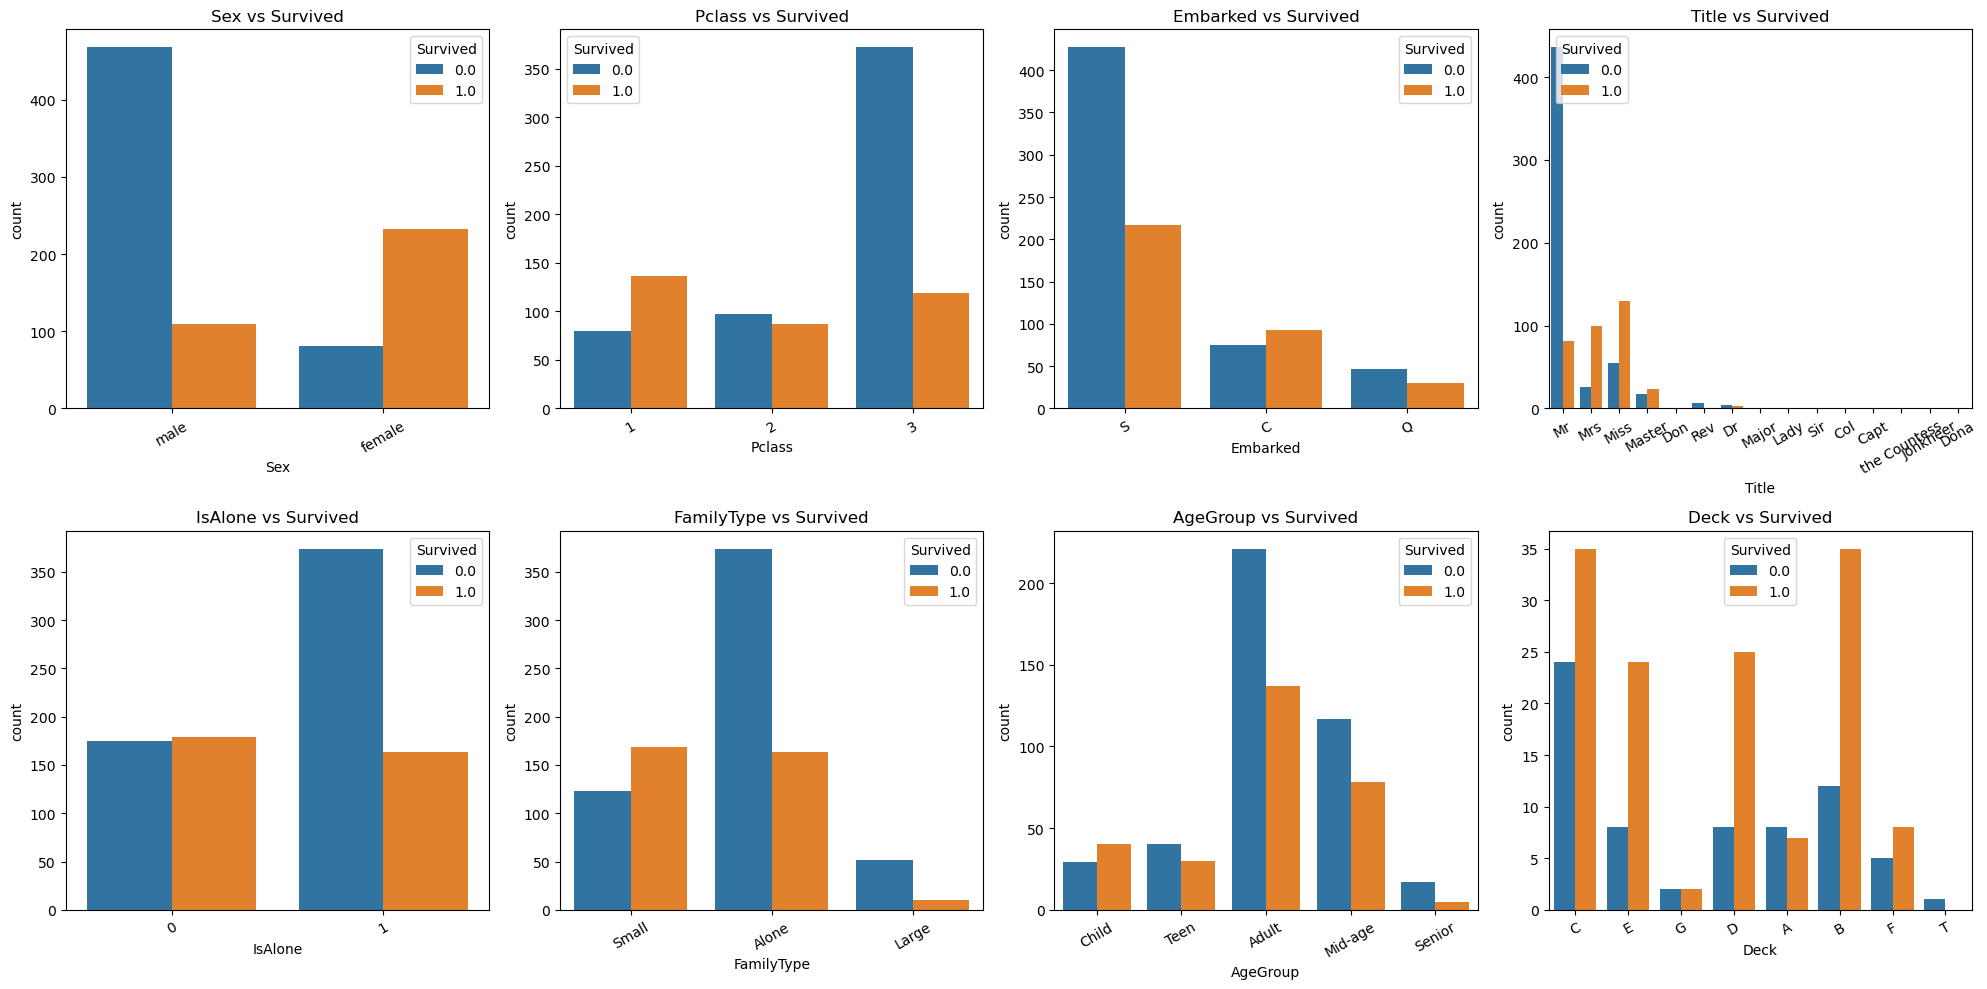

In [37]:
cat_features = ["Sex", "Pclass", "Embarked", "Title",
                "IsAlone", "FamilyType", "AgeGroup", "Deck"]

plt.figure(figsize=(20, 10))

for i, col in enumerate(cat_features, 1):
    plt.subplot(2, 4, i)
    sns.countplot(data=df, x=col, hue="Survived")
    plt.title(f"{col} vs Survived")
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


In [38]:
for col in ["Sex", "Pclass", "Title", "FamilyType","Embarked","AgeGroup","Deck"]:
    print(f"\n{col} vs Survived (rate):")
    print(pd.crosstab(df[col], df["Survived"], normalize="index").round(2))


Sex vs Survived (rate):
Survived   0.0   1.0
Sex                 
female    0.26  0.74
male      0.81  0.19

Pclass vs Survived (rate):
Survived   0.0   1.0
Pclass              
1         0.37  0.63
2         0.53  0.47
3         0.76  0.24

Title vs Survived (rate):
Survived       0.0   1.0
Title                   
Capt          1.00  0.00
Col           0.50  0.50
Don           1.00  0.00
Dr            0.57  0.43
Jonkheer      1.00  0.00
Lady          0.00  1.00
Major         0.50  0.50
Master        0.42  0.57
Miss          0.30  0.70
Mr            0.84  0.16
Mrs           0.21  0.79
Rev           1.00  0.00
Sir           0.00  1.00
the Countess  0.00  1.00

FamilyType vs Survived (rate):
Survived     0.0   1.0
FamilyType            
Alone       0.70  0.30
Large       0.84  0.16
Small       0.42  0.58

Embarked vs Survived (rate):
Survived   0.0   1.0
Embarked            
C         0.45  0.55
Q         0.61  0.39
S         0.66  0.34

AgeGroup vs Survived (rate):
Survived   0.0   1.

### Categoricalâ€“Categorical Analysis â€” Conclusion

- **Sex** mattered the most. About **74% of women survived**, but only **19% of men**.
- Survival went down with class. **1st class** had the best survival, then 2nd class, then 3rd class.
- People with the title **Mrs and Miss** survived the most. **Master** (young boys) also survived well, while **Mr** had the lowest survival.
- People in **small families** survived more often. People who were alone or in large families survived less.
- **Children** survived more often than adults.
- People with a known cabin/deck usually had a better chance to survive.
- People who boarded at **Cherbourg (C)** survived more, mainly because more 1st-class people boarded there.

### 2. Numerical-Numerical -

| Pair | Why Analyze It? |
|------|----------------|
| Age vs Fare | To check whether older passengers generally paid higher fares. |
| FamilySize vs Fare | To see whether larger families paid more fares because they likely purchased more tickets. |
| SibSp vs Parch | Both represent family relationships. This analysis helps us understand whether they increase together. |

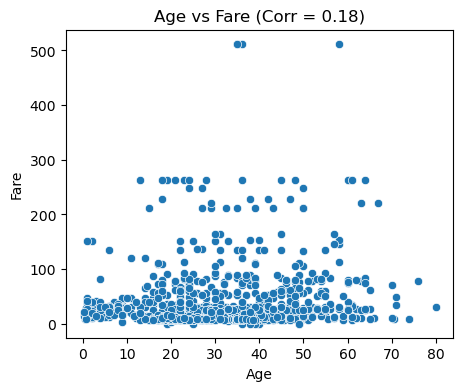

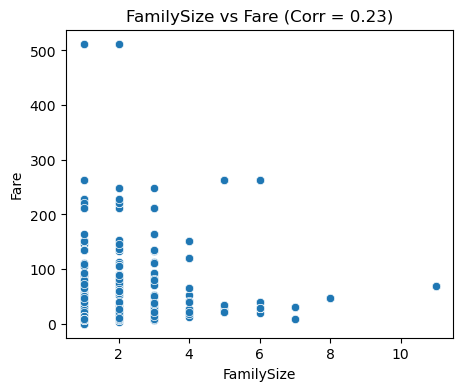

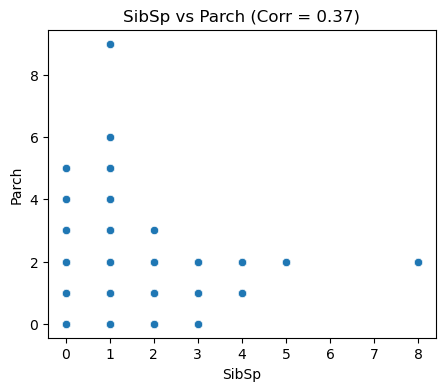

In [39]:
plt.figure(figsize=(5,4))
sns.scatterplot(data=df, x="Age", y="Fare")
plt.title(f"Age vs Fare (Corr = {round(df['Age'].corr(df['Fare']),2)})")
plt.show()

plt.figure(figsize=(5,4))
sns.scatterplot(data=df, x="FamilySize", y="Fare")
plt.title(f"FamilySize vs Fare (Corr = {round(df['FamilySize'].corr(df['Fare']),2)})")
plt.show()

plt.figure(figsize=(5,4))
sns.scatterplot(data=df, x="SibSp", y="Parch")
plt.title(f"SibSp vs Parch (Corr = {round(df['SibSp'].corr(df['Parch']),2)})")
plt.show()

### Numericalâ€“Numerical â€” Conclusion

- **Age vs Fare:** very weak link (corr â‰ˆ 0.18). Older people did not always pay more.
- **FamilySize vs Fare:** small positive link (corr â‰ˆ 0.23). Bigger groups paid a higher total fare, which makes sense (more tickets together).
- **SibSp vs Parch:** medium positive link (corr â‰ˆ 0.37). Family members usually travelled together.

**Takeaway:** These number columns do not have a strong link with each other.

### 3. Numerical-Categorical -

| Pair | Why Analyze It? |
|------|----------------|
| Survived vs Age | To check whether the age distribution of survivors was different from non-survivors. |
| Survived vs Fare | To see whether passengers who survived generally paid higher fares. |
| Pclass vs Fare | To understand the relationship between passenger class and fare. |
| Pclass vs Age | To check whether passengers in higher classes were generally older. |
| Sex vs Age / Sex vs Fare | To examine differences in age and fare between male and female passengers. |

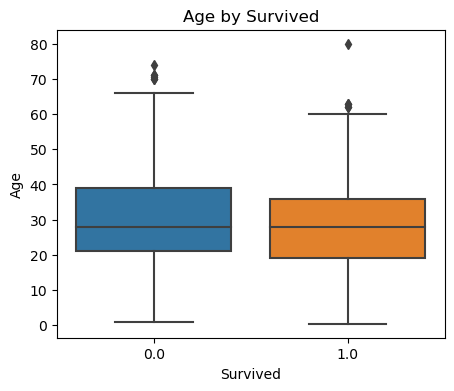

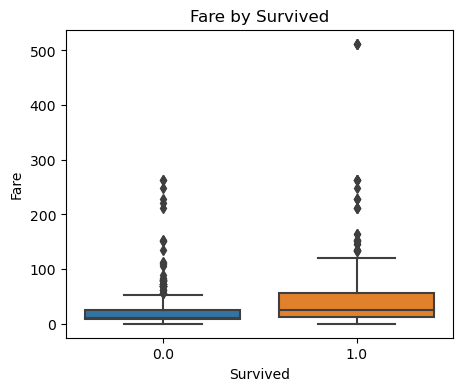

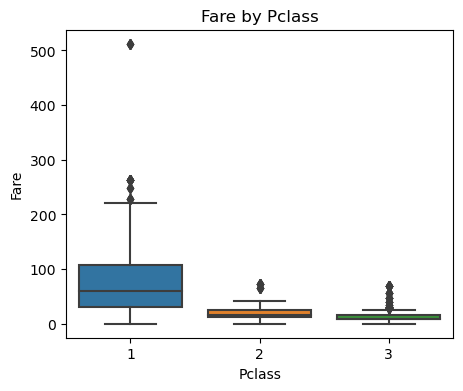

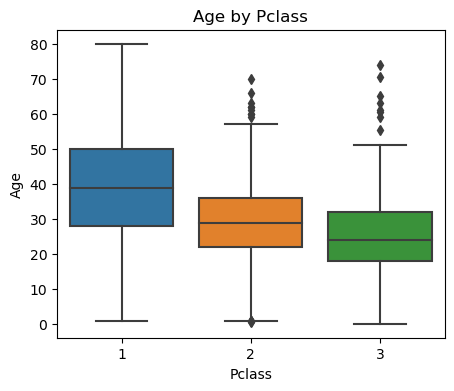

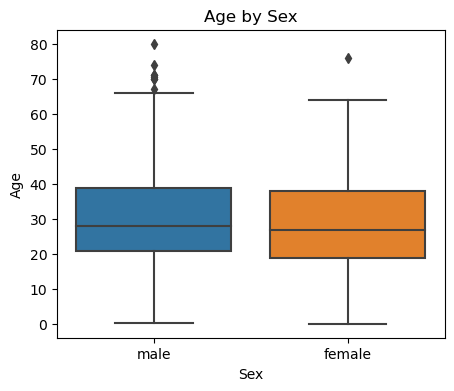

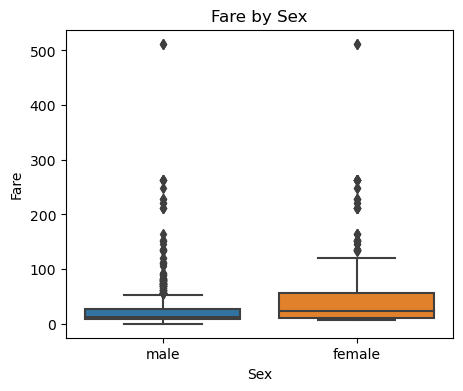

In [40]:
plt.figure(figsize=(5,4))
sns.boxplot(data=df, x="Survived", y="Age")
plt.title("Age by Survived")
plt.show()

plt.figure(figsize=(5,4))
sns.boxplot(data=df, x="Survived", y="Fare")
plt.title("Fare by Survived")
plt.show()

plt.figure(figsize=(5,4))
sns.boxplot(data=df, x="Pclass", y="Fare")
plt.title("Fare by Pclass")
plt.show()

plt.figure(figsize=(5,4))
sns.boxplot(data=df, x="Pclass", y="Age")
plt.title("Age by Pclass")
plt.show()

plt.figure(figsize=(5,4))
sns.boxplot(data=df, x="Sex", y="Age")
plt.title("Age by Sex")
plt.show()

plt.figure(figsize=(5,4))
sns.boxplot(data=df, x="Sex", y="Fare")
plt.title("Fare by Sex")
plt.show()

### Numericalâ€“Categorical â€” Conclusion

- **Fare vs Survived:** People who survived usually paid a higher fare.
- **Age vs Survived:** The age gap is small, but survivors were a little younger on average.
- **Pclass vs Fare:** 1st-class people paid much higher fares than 2nd and 3rd class.
- **Pclass vs Age:** People in higher classes were usually older.
- **Sex vs Fare:** Women paid a little more on average.
- **Sex vs Age:** Men and women had a similar age range.

**Takeaway:** People who paid higher fares and were in higher classes had a better chance to survive. Survivors were also a little younger.

## (iii) Multivariate Analysis

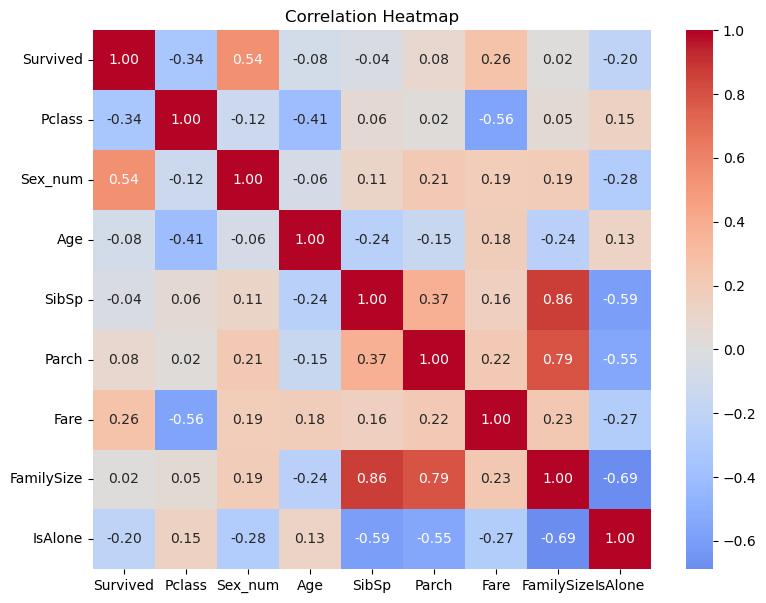

In [41]:
num  = df.assign(Sex_num=df["Sex"].map({"male": 0, "female": 1}))
corr = num[["Survived","Pclass","Sex_num","Age","SibSp","Parch","Fare","FamilySize","IsAlone"]].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap"); plt.show()

### Correlation Heatmap â€” Conclusion

- **Sex** has the strongest link with survival. Women were more likely to survive than men.
- **Pclass** is also important. 1st-class people had a better chance to survive than lower classes.
- **Fare** has a positive link with survival â€” people who paid more were more likely to survive.
- **IsAlone** has a small negative link â€” people travelling alone had a lower chance to survive.
- Most other columns have weak links with each other, so they give different information about the passengers.

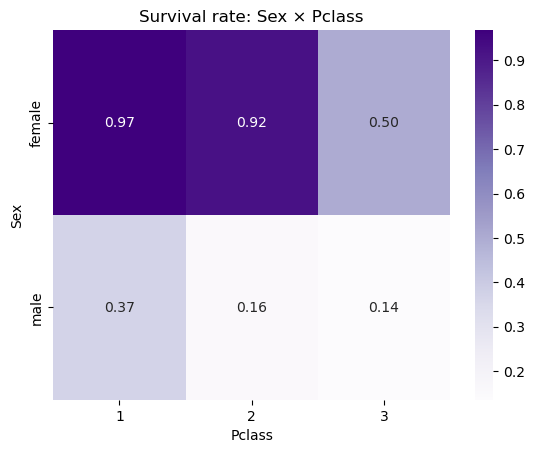

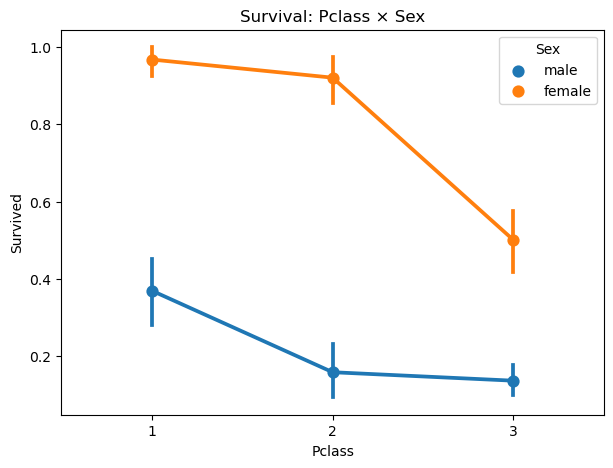

In [42]:
# Sex Ã— Pclass -> survival rate
data = df.pivot_table(index="Sex", columns="Pclass", values="Survived")
sns.heatmap(data, annot=True, fmt=".2f", cmap="Purples")
plt.title("Survival rate: Sex Ã— Pclass"); plt.show()

# Pclass Ã— Sex interaction
plt.figure(figsize=(7, 5))
sns.pointplot(data=df, x="Pclass", y="Survived", hue="Sex")
plt.title("Survival: Pclass Ã— Sex"); plt.show()

### Conclusion

- **Sex Ã— Pclass (heatmap and pointplot):** this is the clearest combined result â€” **1st-class women had about 97% survival, while 3rd-class men had only about 14%**. Women survived more than men in every class, but the gap was bigger in the lower classes.

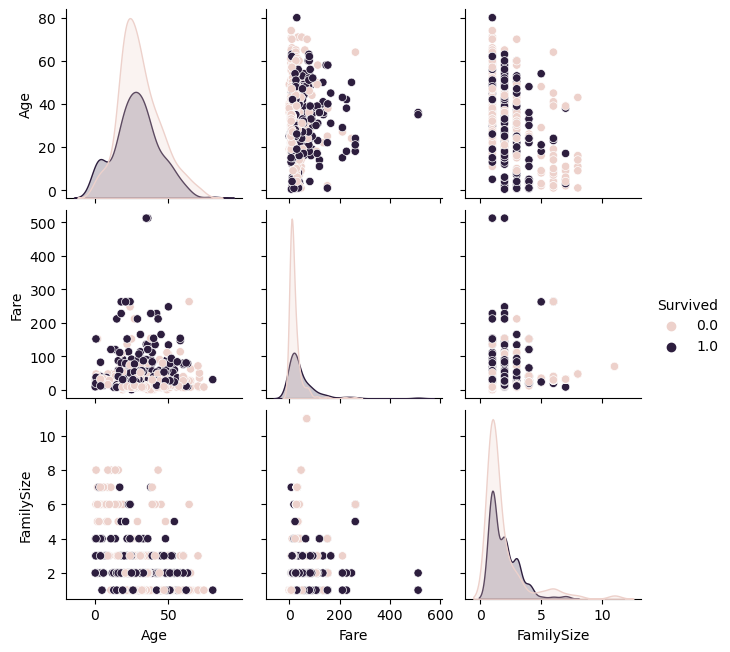

In [43]:
sns.pairplot(df, vars=["Age", "Fare", "FamilySize"], hue="Survived", height=2.2)
plt.show()

### Conclusion

**Pairplot and scatter plots:** survivors are mostly **younger people who paid a higher fare**. The Ageâ€“Fare plot alone has no clear pattern, but adding colour (Survived) and shape (Sex) makes the pattern clear.

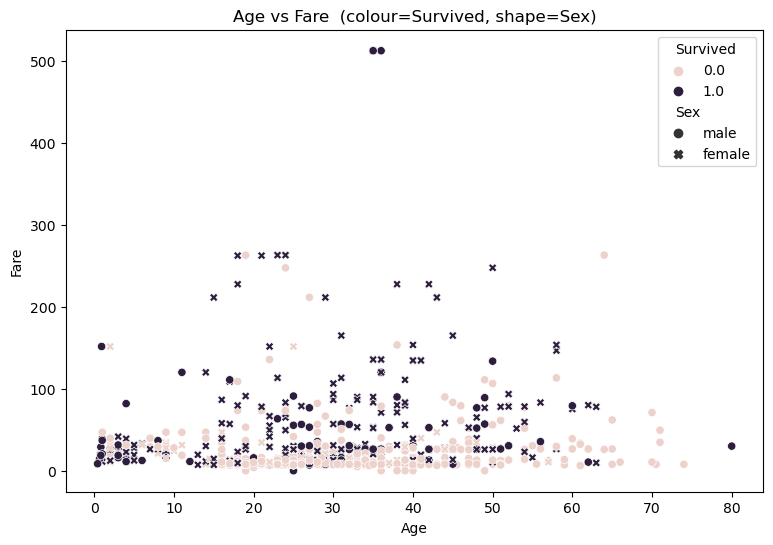

In [44]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="Age", y="Fare", hue="Survived", style="Sex")
plt.title("Age vs Fare  (colour=Survived, shape=Sex)"); plt.show()

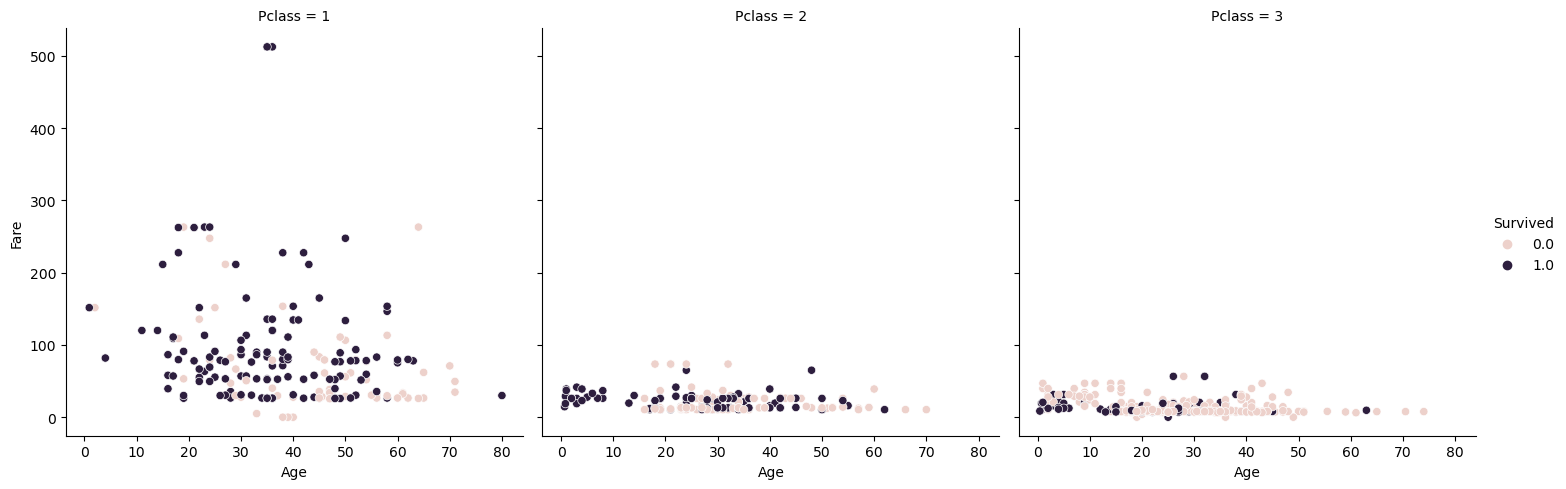

In [45]:
sns.relplot(data=df, x="Age", y="Fare", hue="Survived", col="Pclass", kind="scatter")
plt.show()

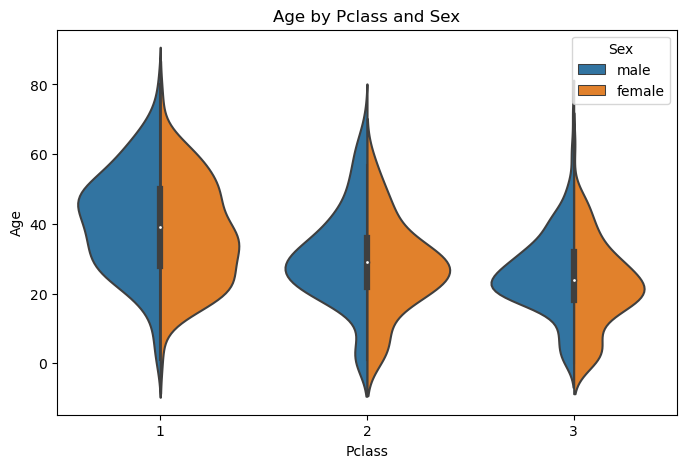

In [46]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x="Pclass", y="Age", hue="Sex", split=True)
plt.title("Age by Pclass and Sex"); plt.show()

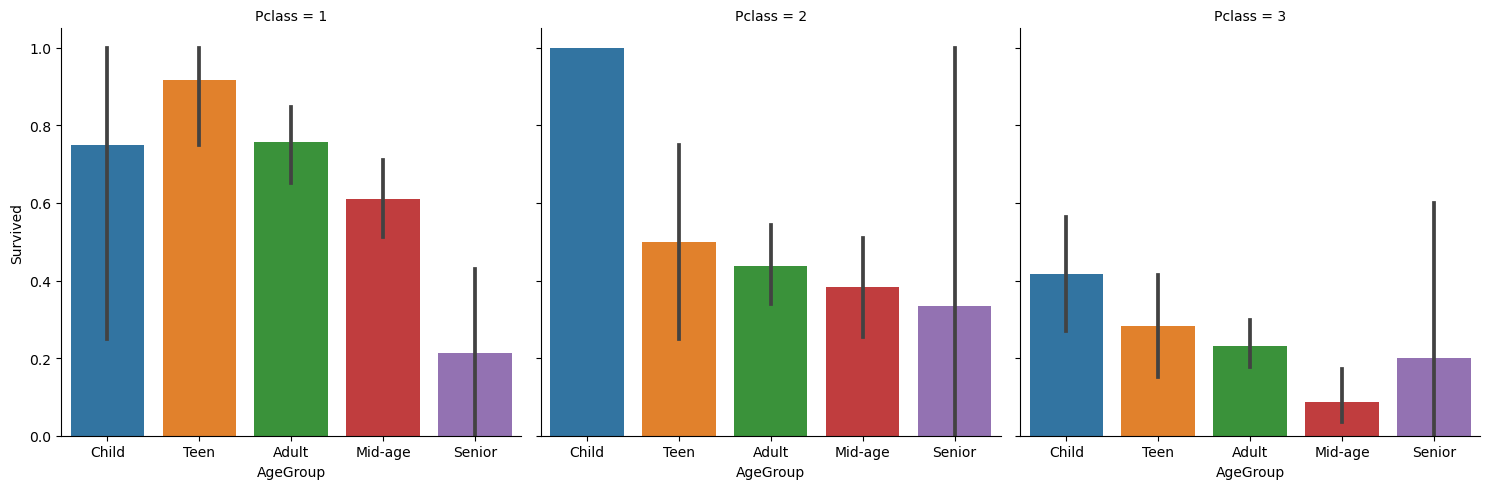

In [47]:
sns.catplot(data=df, x="AgeGroup", y="Survived", col="Pclass", kind="bar")
plt.show()

### Conclusion

- **Age Ã— Fare by Pclass (relplot):** survivors are mostly in the higher-fare area, especially in 1st class.
- **Age Ã— Pclass Ã— Sex (violin):** higher classes had older people, and women survived more than men at every age within each class.
- **AgeGroup Ã— Pclass (catplot):** children in 1st and 2nd class survived a lot, while 3rd-class people of all ages had a hard time.

**Takeaway:** Survival depended mostly on **Sex and Pclass together** â€” being a woman in a higher class gave the best chance. This matches the "women and upper-class first" rescue. Age and Fare add a smaller effect (younger, higher-paying people did a little better).

# Handling Null Values :-

In [48]:
new_df = df.copy()

In [49]:
new_df.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsAlone,FamilyType,AgeGroup,IndividualFare,Deck
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,Mr,2,0,Small,Adult,3.625,NaN


In [50]:
def compare_fillvalues(new_df, col):
    s = new_df[col]
    n_missing = s.isnull().sum()
    print(f"Column: {col}  |  Missing: {n_missing} ({n_missing/len(s)*100:.1f}%)")
    if n_missing == 0:
        print("Koi missing value nahi."); return

    if pd.api.types.is_numeric_dtype(s):
        # -------- NUMERICAL --------
        original    = s.dropna()
        mean_fill   = s.fillna(s.mean())
        median_fill = s.fillna(s.median())
        random_fill = s.copy()                                  # existing values mein se random sample
        random_fill.loc[random_fill.isnull()] = s.dropna().sample(n_missing, replace=True, random_state=1).values

        print("\nVariance (original ke jitna kareeb, utna behtar):")
        for name, ser in [("Original", original), ("Mean", mean_fill),
                          ("Median", median_fill), ("Random", random_fill)]:
            print(f"  {name:8}: var = {ser.var():8.2f}   std = {ser.std():6.2f}")

        plt.figure(figsize=(8, 4))
        sns.kdeplot(original,    label="Original",    linewidth=2.5)
        sns.kdeplot(mean_fill,   label="Mean fill")
        sns.kdeplot(median_fill, label="Median fill")
        sns.kdeplot(random_fill, label="Random fill")
        plt.title(f"{col} â€” distribution after each fill method")
        plt.legend(); plt.show()

    else:
        # -------- CATEGORICAL --------
        s = s.astype(object)                                    # category-dtype safety (AgeGroup etc.)
        mode_val     = s.mode()[0]
        mode_fill    = s.fillna(mode_val)
        missing_fill = s.fillna("Missing")
        random_fill  = s.copy()
        random_fill.loc[random_fill.isnull()] = s.dropna().sample(n_missing, replace=True, random_state=1).values

        print(f"\nMode value: '{mode_val}'")
        print(f"  Mode category ka share -> Original: {(s==mode_val).sum()/s.notna().sum()*100:.1f}%"
              f"   |   Mode-fill ke baad: {(mode_fill==mode_val).sum()/len(mode_fill)*100:.1f}%")

        methods = [("Original", s.dropna()), ("Mode fill", mode_fill),
                   ("Random fill", random_fill), ("'Missing' category", missing_fill)]
        fig, ax = plt.subplots(1, 4, figsize=(20, 4))
        for i, (name, ser) in enumerate(methods):
            sns.countplot(x=ser, order=ser.value_counts().index[:15], ax=ax[i])   # top 15 (high-card guard)
            ax[i].set_title(name); ax[i].tick_params(axis="x", rotation=45)
        plt.tight_layout(); plt.show()

In [51]:
new_df.isnull().mean()*100

PassengerId        0.000000
Survived          31.932773
Pclass             0.000000
Name               0.000000
Sex                0.000000
Age               20.091673
SibSp              0.000000
Parch              0.000000
Ticket             0.000000
Fare               0.076394
Cabin             77.463713
Embarked           0.152788
Title              0.000000
FamilySize         0.000000
IsAlone            0.000000
FamilyType         0.000000
AgeGroup          20.091673
IndividualFare     0.076394
Deck              77.463713
dtype: float64

### AGE :-

Column: Age  |  Missing: 263 (20.1%)

Variance (original ke jitna kareeb, utna behtar):
  Original: var =   207.75   std =  14.41
  Mean    : var =   165.98   std =  12.88
  Median  : var =   166.55   std =  12.91
  Random  : var =   204.22   std =  14.29


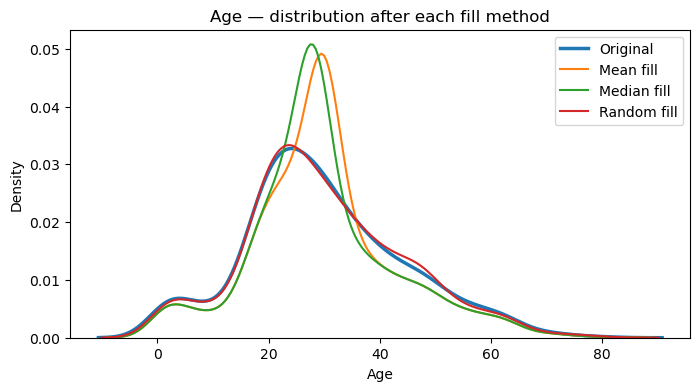

In [52]:
compare_fillvalues(new_df, "Age")

In [53]:
n_missing = new_df['Age'].isnull().sum()
new_df.loc[new_df['Age'].isnull(), 'Age'] = (
    df['Age'].dropna().sample(n_missing, replace=True, random_state=42).values
)

In [54]:
new_df['Age'].isnull().sum()

0

### Cabin :-

Column: Cabin  |  Missing: 1014 (77.5%)

Mode value: 'C23 C25 C27'
  Mode category ka share -> Original: 2.0%   |   Mode-fill ke baad: 77.9%


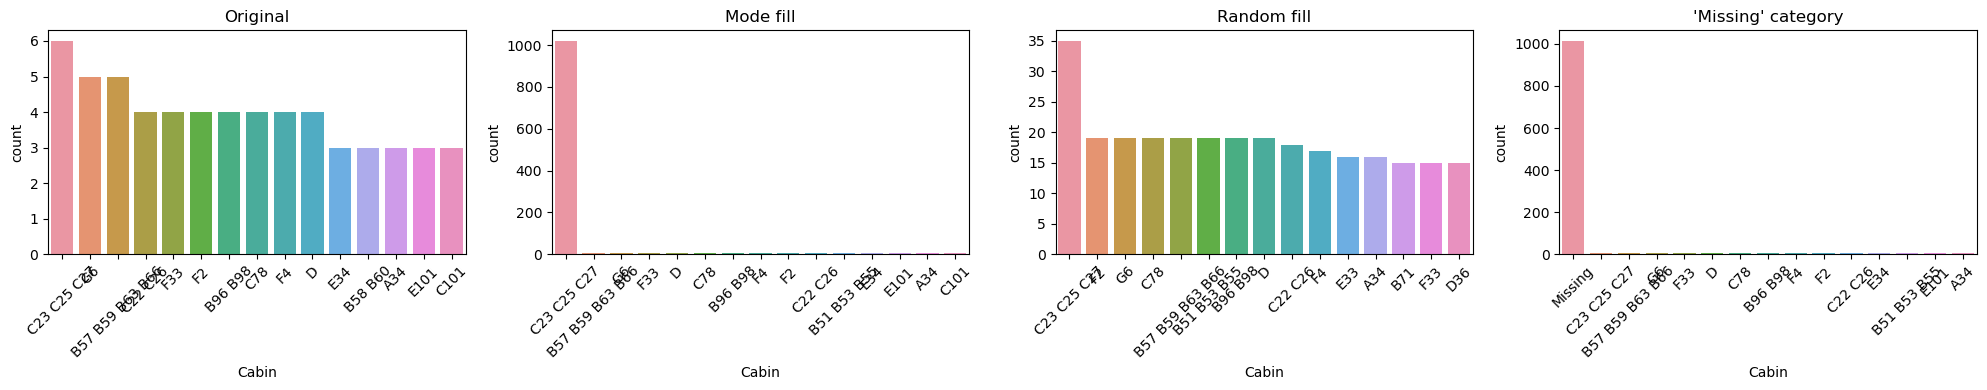

In [55]:
compare_fillvalues(new_df, "Cabin")

In [56]:
new_df["Cabin"] = new_df["Cabin"].fillna("Unknown")

In [57]:
new_df['Cabin'].isnull().sum()

0

### Deck :-

Column: Deck  |  Missing: 1014 (77.5%)

Mode value: 'C'
  Mode category ka share -> Original: 31.9%   |   Mode-fill ke baad: 84.6%


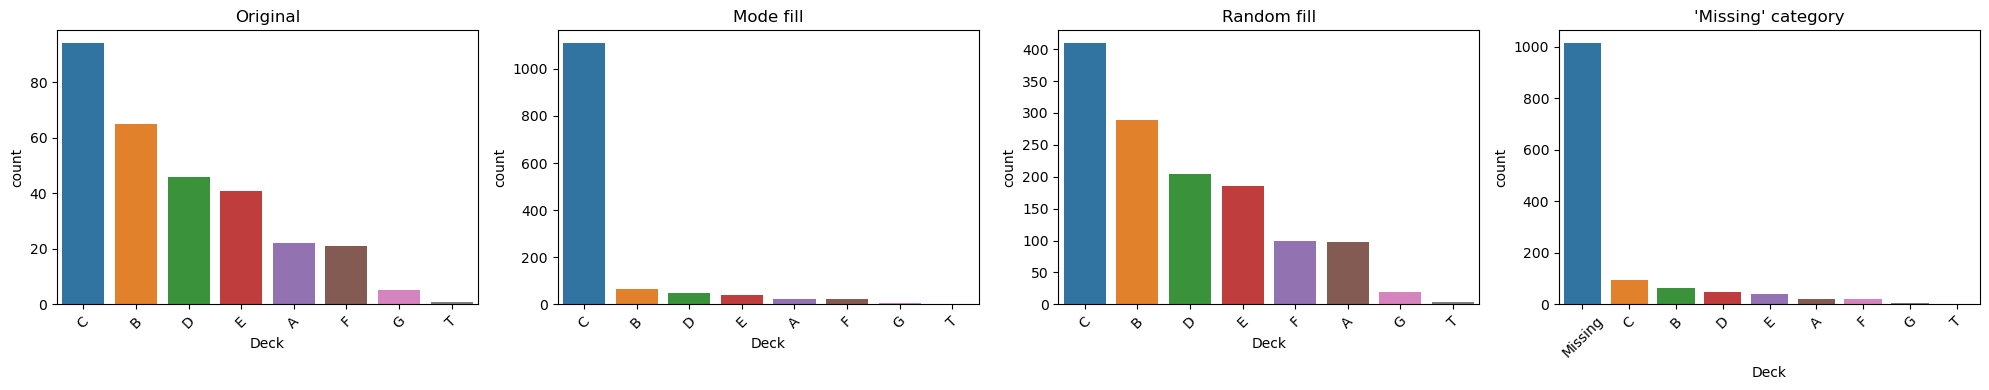

In [58]:
compare_fillvalues(new_df, "Deck")

In [59]:
new_df["Deck"] = new_df["Cabin"].str[0]   

In [60]:
new_df['Deck'].isnull().sum()

0

### AgeGroup :-

In [61]:
new_df['AgeGroup'].isnull().sum()

263

In [62]:
new_df['AgeGroup'].notnull().sum()

1046

In [63]:
bins = [0, 12, 18, 35, 60, 200]
labels = ["Child", "Teen", "Adult", "Mid-age", "Senior"]
new_df["AgeGroup"] = pd.cut(new_df["Age"], bins=bins, labels=labels)

In [64]:
new_df['AgeGroup'].isnull().sum()

0

### Survived :-

In [65]:
print("Real labels (train) :", new_df['Survived'].notna().sum())
print("Missing (test rows) :", new_df['Survived'].isnull().sum())

Real labels (train) : 891
Missing (test rows) : 418


### Embarked :-

Column: Embarked  |  Missing: 2 (0.2%)

Mode value: 'S'
  Mode category ka share -> Original: 69.9%   |   Mode-fill ke baad: 70.0%


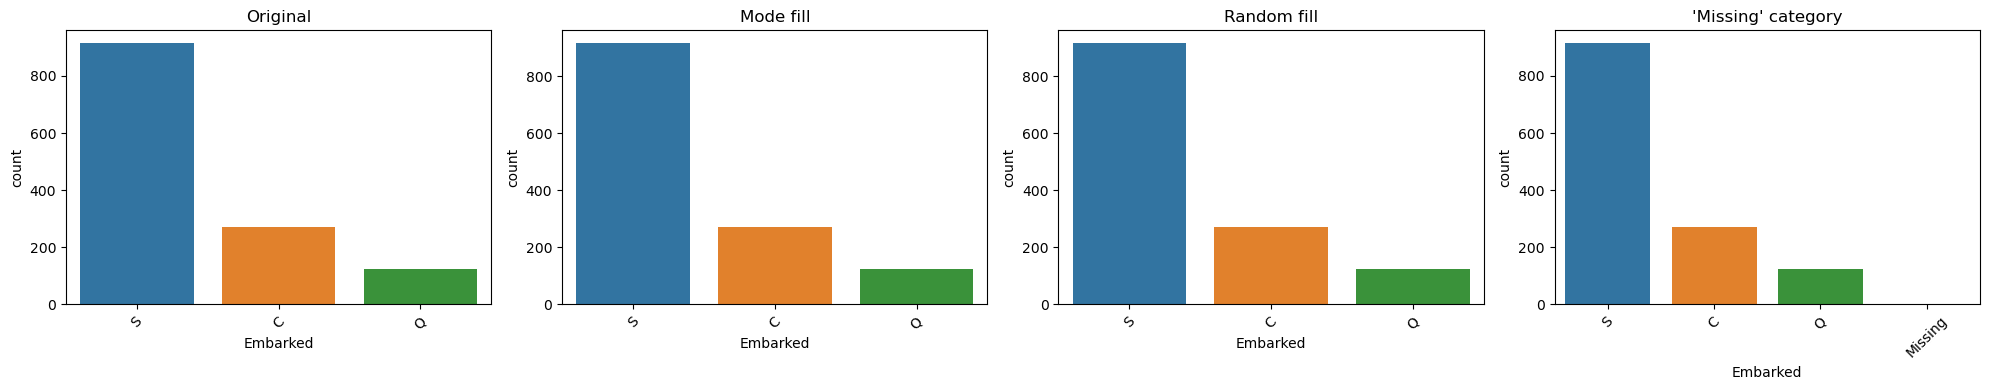

In [66]:
compare_fillvalues(new_df,"Embarked" )

In [67]:
new_df["Embarked"] = new_df["Embarked"].fillna(new_df["Embarked"].mode()[0])

In [68]:
new_df['Embarked'].isnull().sum()

0

### Fare :-

Column: Fare  |  Missing: 1 (0.1%)

Variance (original ke jitna kareeb, utna behtar):
  Original: var =  2678.96   std =  51.76
  Mean    : var =  2676.91   std =  51.74
  Median  : var =  2677.18   std =  51.74
  Random  : var =  2677.43   std =  51.74


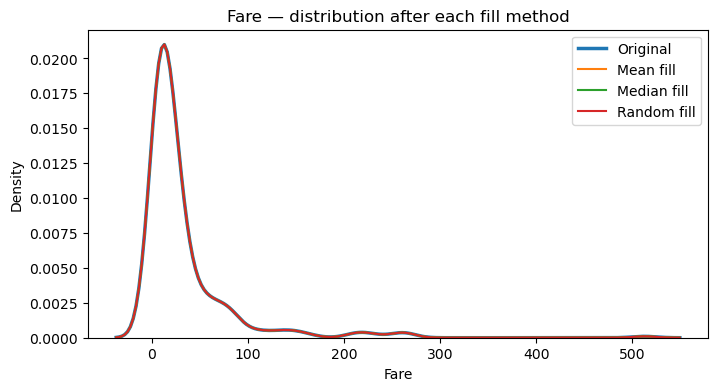

In [69]:
compare_fillvalues(new_df,"Fare")

In [70]:
new_df["Fare"] = new_df["Fare"].fillna(df["Fare"].median()) 

In [71]:
new_df["IndividualFare"] = new_df["Fare"] / new_df["FamilySize"]

In [72]:
counts = df["Title"].value_counts()
rare = counts[counts < 10].index          # Dr, Rev, Col, Major, Capt, Sir, Lady...
df["Title"] = df["Title"].replace(rare, "Rare")
df["Title"].value_counts()

Mr        757
Miss      264
Mrs       198
Master     61
Rare       29
Name: Title, dtype: int64

### Handling Null Values â€” Conclusion

For each column with missing values, we picked a fill method after comparing a few options:

- **Age (~20% missing):** filled by taking **random values** from the ages we already have. This kept the spread close to the original (variance â‰ˆ204 vs 208), while mean/median fill made it smaller (â‰ˆ166). So random fill kept the data most natural.
- **Cabin (~77% missing):** too many values were missing to fill properly, so we put **"Unknown"** in the empty ones.
- **Deck:** made again from the filled Cabin column.
- **AgeGroup:** made again from the filled Age values, so its missing values were fixed automatically.
- **Embarked (2 missing):** filled with the **most common port ("S")**, Southampton.
- **Fare (1 missing):** filled with the **median**, which is not affected by the very high fares.
- **Survived:** left empty on purpose â€” these are the test rows, so we do not fill them.

**Takeaway:** All missing values are now handled (except the Survived column, which is empty on purpose). We chose fill methods that keep the data close to the original instead of just using a default value.

# Handling Outliers :-

In [73]:
def outlier_detection_iqr(new_df, col):
    Q1 = new_df[col].quantile(0.25)
    Q3 = new_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = new_df[(new_df[col] < lower) | (new_df[col] > upper)]

    print("Lower Bound:", round(lower,2))
    print("Upper Bound:", round(upper,2))

    return outliers

outlier_detection_iqr(new_df, "Fare")    

Lower Bound: -27.17
Upper Bound: 66.34


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsAlone,FamilyType,AgeGroup,IndividualFare,Deck
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2,0,Small,Mid-age,35.641650,C
27,28,0.0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S,Mr,6,0,Large,Adult,43.833333,C
31,32,1.0,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,6.0,1,0,PC 17569,146.5208,B78,C,Mrs,2,0,Small,Child,73.260400,B
34,35,0.0,1,"Meyer, Mr. Edgar Joseph",male,28.0,1,0,PC 17604,82.1708,Unknown,C,Mr,2,0,Small,Adult,41.085400,U
52,53,1.0,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.0,1,0,PC 17572,76.7292,D33,C,Mrs,2,0,Small,Mid-age,38.364600,D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1288,1289,NaN,1,"Frolicher-Stehli, Mrs. Maxmillian (Margaretha ...",female,48.0,1,1,13567,79.2000,B41,C,Mrs,3,0,Small,Mid-age,26.400000,B
1291,1292,NaN,1,"Bonnell, Miss. Caroline",female,30.0,0,0,36928,164.8667,C7,S,Miss,1,1,Alone,Adult,164.866700,C
1298,1299,NaN,1,"Widener, Mr. George Dunton",male,50.0,1,1,113503,211.5000,C80,C,Mr,3,0,Small,Mid-age,70.500000,C
1302,1303,NaN,1,"Minahan, Mrs. William Edward (Lillian E Thorpe)",female,37.0,1,0,19928,90.0000,C78,Q,Mrs,2,0,Small,Mid-age,45.000000,C


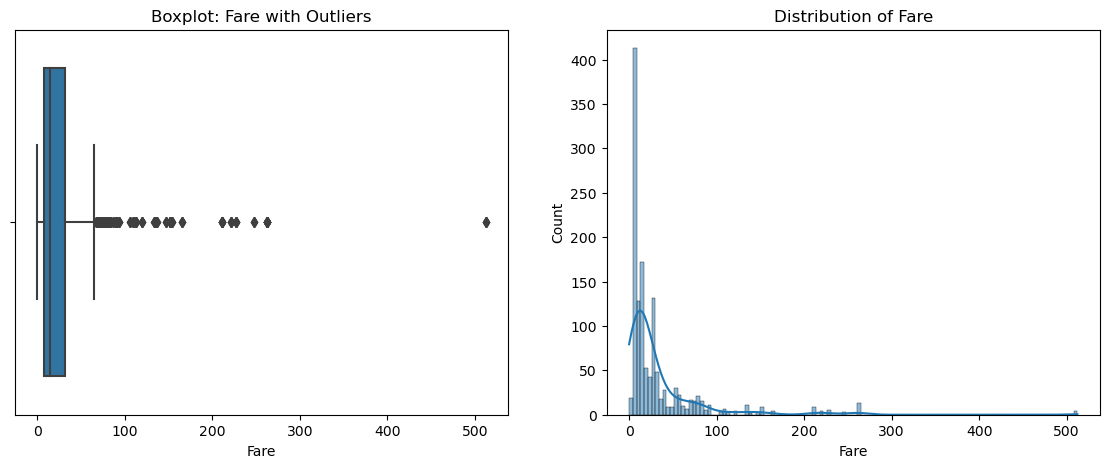

In [74]:
def outlier_plot(new_df,col):
    plt.figure(figsize=(14,5))

    plt.subplot(1,2,1)
    sns.boxplot(data = new_df, x=new_df[col])
    plt.title(f"Boxplot: {col} with Outliers")

    plt.subplot(1,2,2)
    sns.histplot(new_df[col], kde=True)
    plt.title(f"Distribution of {col}")

    plt.show()
outlier_plot(new_df,'Fare')

In [75]:
def capping_outliers(new_df,col):
    Q1 = new_df[col].quantile(0.25)
    Q3 = new_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    new_df[col] = new_df[col].clip(lower, upper)
    print(f"{col}Outliers Treated Using Capping.")
    return new_df

capping_outliers(new_df,"Fare")


FareOutliers Treated Using Capping.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsAlone,FamilyType,AgeGroup,IndividualFare,Deck
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S,Mr,2,0,Small,Adult,3.625000,U
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,66.3438,C85,C,Mrs,2,0,Small,Mid-age,35.641650,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,Miss,1,1,Alone,Adult,7.925000,U
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2,0,Small,Adult,26.550000,C
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S,Mr,1,1,Alone,Adult,8.050000,U
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,3,"Spector, Mr. Woolf",male,33.0,0,0,A.5. 3236,8.0500,Unknown,S,Mr,1,1,Alone,Adult,8.050000,U
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,66.3438,C105,C,Dona,1,1,Alone,Mid-age,108.900000,C
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,Unknown,S,Mr,1,1,Alone,Mid-age,7.250000,U
1307,1308,NaN,3,"Ware, Mr. Frederick",male,64.0,0,0,359309,8.0500,Unknown,S,Mr,1,1,Alone,Senior,8.050000,U


In [76]:
new_df["IndividualFare"] = new_df["Fare"] / new_df["FamilySize"]

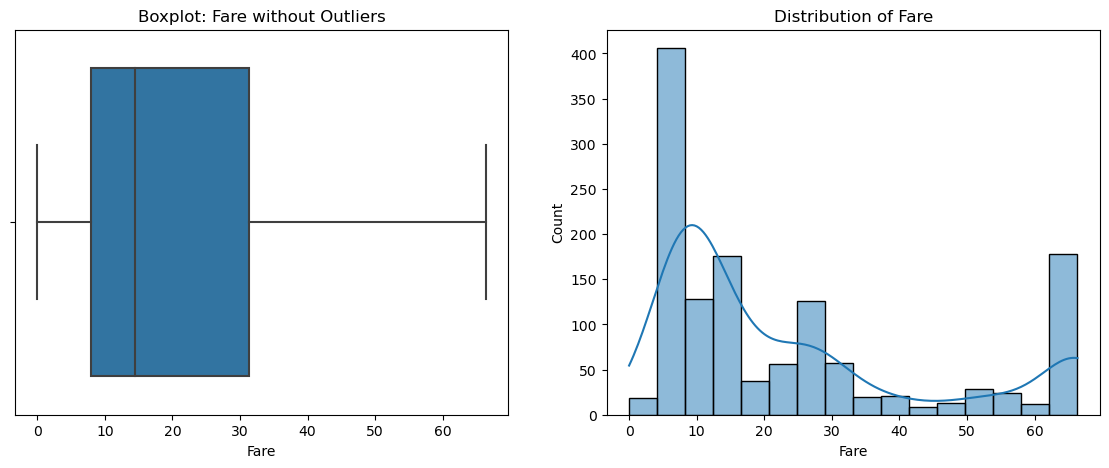

In [77]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.boxplot(data = new_df , x=new_df['Fare'])
plt.title(f"Boxplot: Fare without Outliers")

plt.subplot(1,2,2)
sns.histplot(new_df['Fare'], kde=True)
plt.title(f"Distribution of Fare")

plt.show()

### Handling Outliers â€” Conclusion

- **Fare** was the main column with very high values. Using the IQR method, any fare above **66.34** was marked as an outlier (the lower limit was negative at -27.17, so only the high side mattered).
- Many fares were above this limit, and the highest fare was **512.33**. Such high values can affect the scale and the model.
- We fixed these using **IQR capping** instead of deleting rows, so no passenger was removed â€” the very high fares were just brought down to the upper limit.
- After capping, the Fare boxplot and distribution look much cleaner and more even.

**Takeaway:** Capping kept all the data and removed the effect of a few very high fares, so Fare is now safer to use in analysis and models.

# Analysis :-

### Missing values: Before vs After table:

In [78]:
missing_compare = pd.DataFrame({
    "Before (%)": (df.isnull().mean() * 100).round(2),
    "After (%)":  (new_df.isnull().mean() * 100).round(2),
})
missing_compare["Status"] = np.where(
    missing_compare["Before (%)"] == 0, "No Missing",
    np.where(missing_compare["After (%)"] == 0, "Fixed", "By Design (target)")
)
missing_compare

,Before (%),After (%),Status
PassengerId,0.00,0.00,No Missing
Survived,31.93,31.93,By Design (target)
Pclass,0.00,0.00,No Missing
Name,0.00,0.00,No Missing
Sex,0.00,0.00,No Missing
Age,20.09,0.00,Fixed
SibSp,0.00,0.00,No Missing
Parch,0.00,0.00,No Missing
Ticket,0.00,0.00,No Missing
Fare,0.08,0.00,Fixed


### Age & Fare distribution: Before vs After:

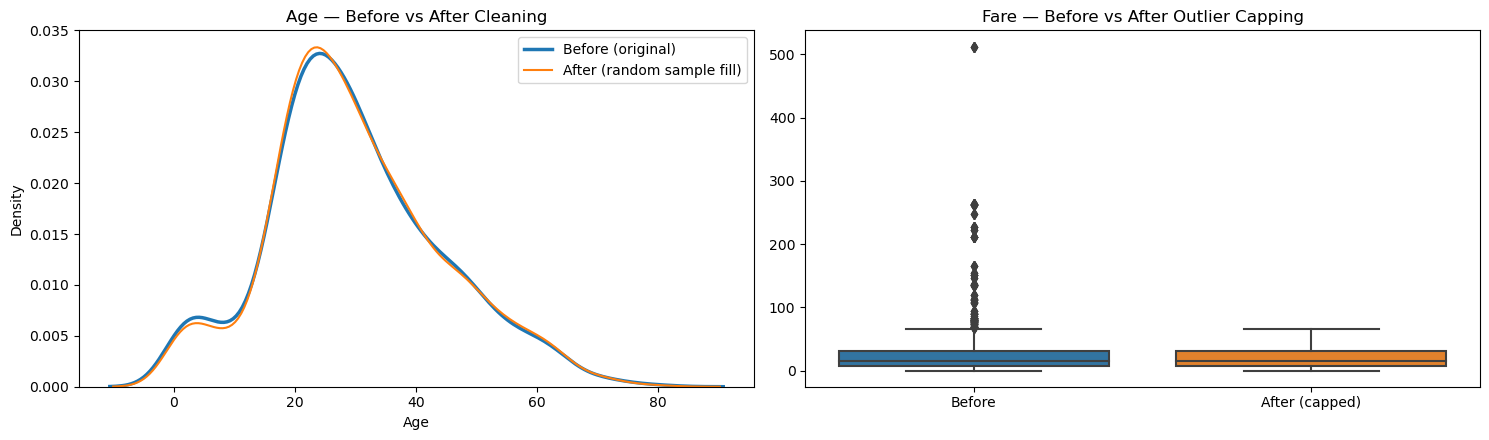

In [79]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))

sns.kdeplot(df["Age"].dropna(), ax=ax[0], label="Before (original)", linewidth=2.5)
sns.kdeplot(new_df["Age"], ax=ax[0], label="After (random sample fill)")
ax[0].set_title("Age â€” Before vs After Cleaning")
ax[0].legend()


fare_compare = pd.DataFrame({"Before": df["Fare"], "After (capped)": new_df["Fare"]})
sns.boxplot(data=fare_compare, ax=ax[1])
ax[1].set_title("Fare â€” Before vs After Outlier Capping")

plt.tight_layout(); plt.show()

### Summary stats comparison:

In [80]:
summary_compare = pd.concat({
    "Age (Before)":  df["Age"].describe(),
    "Age (After)":   new_df["Age"].describe(),
    "Fare (Before)": df["Fare"].describe(),
    "Fare (After)":  new_df["Fare"].describe(),
}, axis=1).round(2)
summary_compare

,Age (Before),Age (After),Fare (Before),Fare (After)
count,1046.00,1309.00,1308.00,1309.00
mean,29.88,30.08,33.30,24.28
std,14.41,14.31,51.76,20.79
min,0.17,0.17,0.00,0.00
25%,21.00,21.00,7.90,7.90
50%,28.00,28.00,14.45,14.45
75%,39.00,39.00,31.28,31.28
max,80.00,80.00,512.33,66.34


### Univariate (After Cleaning):

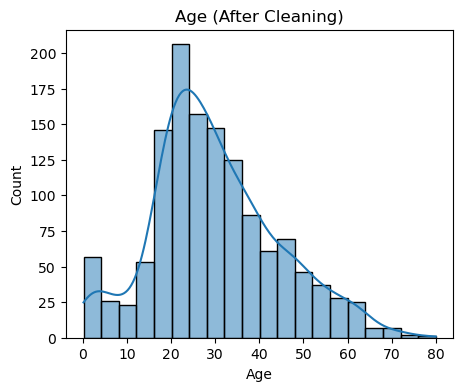

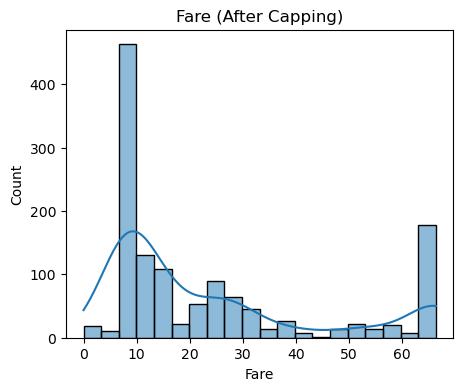

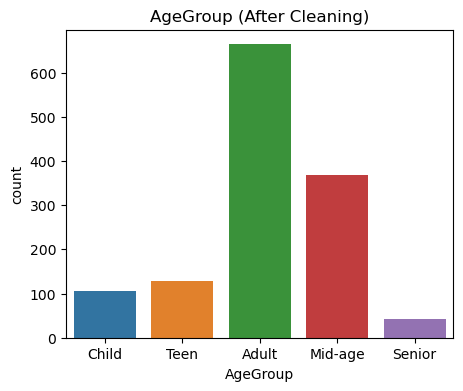

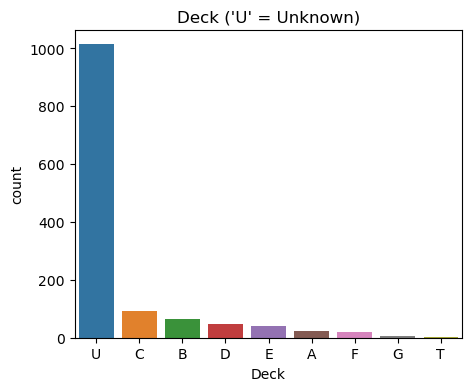

In [81]:
plt.figure(figsize=(5,4))
sns.histplot(new_df["Age"], bins=20, kde=True)
plt.title("Age (After Cleaning)")
plt.show()

plt.figure(figsize=(5,4))
sns.histplot(new_df["Fare"], bins=20, kde=True)
plt.title("Fare (After Capping)")
plt.show()

plt.figure(figsize=(5,4))
sns.countplot(data=new_df, x="AgeGroup")
plt.title("AgeGroup (After Cleaning)")
plt.show()

plt.figure(figsize=(5,4))
sns.countplot(data=new_df,
              x="Deck",
              order=new_df["Deck"].value_counts().index)
plt.title("Deck ('U' = Unknown)")
plt.show()

### Bivariate (After Cleaning):

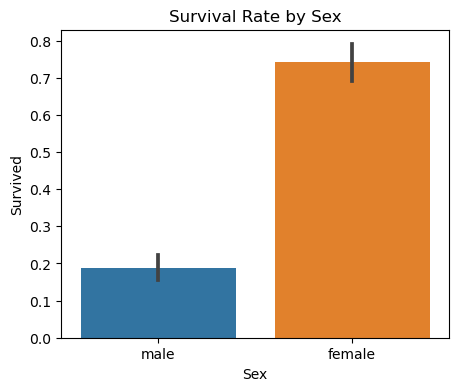

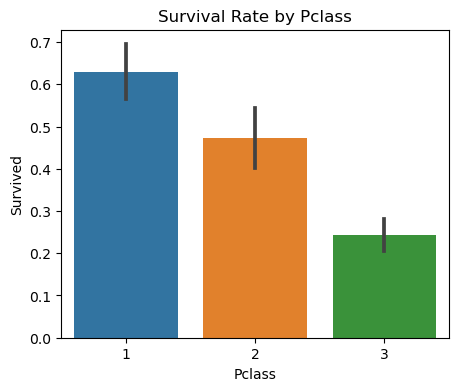

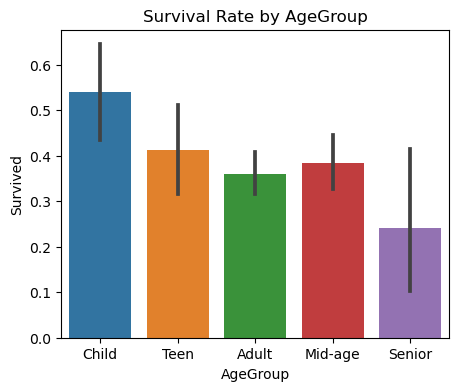

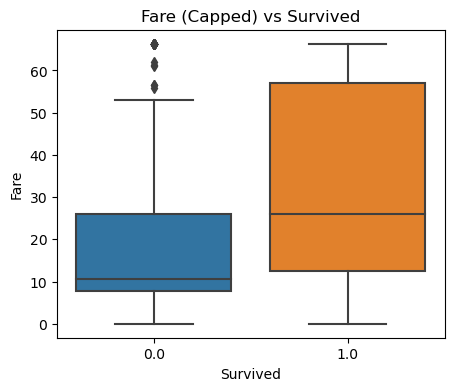

In [82]:
plt.figure(figsize=(5,4))
sns.barplot(data=new_df, x="Sex", y="Survived")
plt.title("Survival Rate by Sex")
plt.show()

plt.figure(figsize=(5,4))
sns.barplot(data=new_df, x="Pclass", y="Survived")
plt.title("Survival Rate by Pclass")
plt.show()

plt.figure(figsize=(5,4))
sns.barplot(data=new_df, x="AgeGroup", y="Survived")
plt.title("Survival Rate by AgeGroup")
plt.show()

plt.figure(figsize=(5,4))
sns.boxplot(data=new_df, x="Survived", y="Fare")
plt.title("Fare (Capped) vs Survived")
plt.show()

###  Survival rate tables:

In [83]:
for col in ["Sex", "Pclass", "Title", "FamilyType","Embarked","AgeGroup","Deck"]:
    print(f"\n{col} vs Survived (rate):")
    print(pd.crosstab(new_df[col], new_df["Survived"], normalize="index").round(2))


Sex vs Survived (rate):
Survived   0.0   1.0
Sex                 
female    0.26  0.74
male      0.81  0.19

Pclass vs Survived (rate):
Survived   0.0   1.0
Pclass              
1         0.37  0.63
2         0.53  0.47
3         0.76  0.24

Title vs Survived (rate):
Survived       0.0   1.0
Title                   
Capt          1.00  0.00
Col           0.50  0.50
Don           1.00  0.00
Dr            0.57  0.43
Jonkheer      1.00  0.00
Lady          0.00  1.00
Major         0.50  0.50
Master        0.42  0.57
Miss          0.30  0.70
Mr            0.84  0.16
Mrs           0.21  0.79
Rev           1.00  0.00
Sir           0.00  1.00
the Countess  0.00  1.00

FamilyType vs Survived (rate):
Survived     0.0   1.0
FamilyType            
Alone       0.70  0.30
Large       0.84  0.16
Small       0.42  0.58

Embarked vs Survived (rate):
Survived   0.0   1.0
Embarked            
C         0.45  0.55
Q         0.61  0.39
S         0.66  0.34

AgeGroup vs Survived (rate):
Survived   0.0   1.

### Multivariate (After Cleaning):

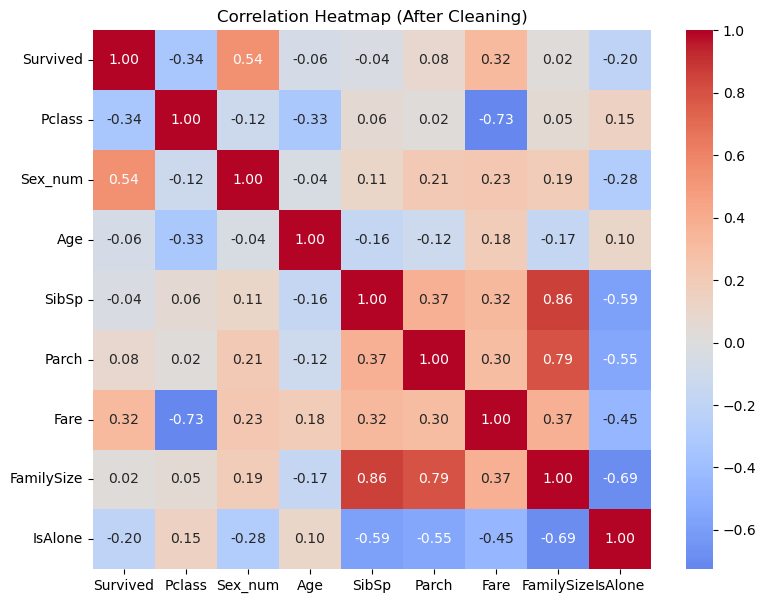

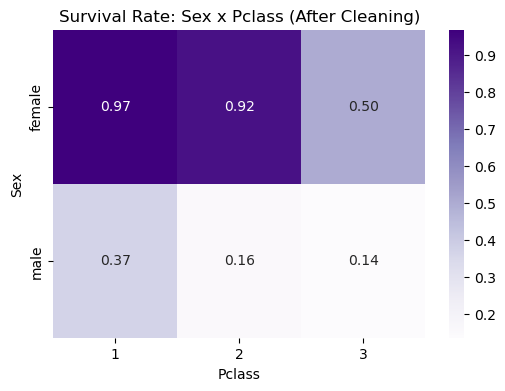

In [84]:
num_clean = new_df.assign(Sex_num=new_df["Sex"].map({"male": 0, "female": 1}))
corr_clean = num_clean[["Survived", "Pclass", "Sex_num", "Age", "SibSp",
                        "Parch", "Fare", "FamilySize", "IsAlone"]].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_clean, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (After Cleaning)")
plt.show()

pivot_clean = new_df.pivot_table(index="Sex", columns="Pclass", values="Survived")
plt.figure(figsize=(6, 4))
sns.heatmap(pivot_clean, annot=True, fmt=".2f", cmap="Purples")
plt.title("Survival Rate: Sex x Pclass (After Cleaning)")
plt.show()

### After Cleaning â€” Conclusion

* After cleaning, the main patterns in the data stayed the same.
* Women had a much higher survival rate (about 74%) than men (about 19%).
* Survival was highest for 1st-class people, then 2nd class, and lowest for 3rd class.
* The Age values stayed similar after the random fill, so no big change was added to the data.
* Even after capping the high Fare values, survivors still paid higher fares than non-survivors.
* All missing values are now handled, except the Survived column in the test data, which is empty on purpose.
* Cleaning made the data better while keeping the original patterns.

**Final Takeaway:** The data is now clean and ready for feature engineering and model building.

# FINAL CONCLUSION :-

## 1. Dataset Summary
- The full Titanic dataset has **1309 passengers** (891 train + 418 test), with 12 original columns and 7 new columns.
- In the train data, only about **38%** of people survived.

## 2. Key Insights
1. **Sex was the biggest factor** â€” about 74% of women survived, but only 19% of men ("women and children first" is clearly seen).
2. **Class mattered a lot** â€” 1st class (~63%) > 2nd class (~47%) > 3rd class (~24%) survival.
3. **Sex and class together give the strongest result** â€” 1st-class women had ~97% survival, but 3rd-class men had only ~14%.
4. **Fare also helps predict survival** â€” a higher fare means a higher class, which means a better chance to survive.
5. **Family size had a best range** â€” small families (2â€“4 members) survived the most. People who were alone or in large families survived less.
6. **Children got priority** â€” especially in 1st and 2nd class. Young boys (title "Master") had a high survival rate.
7. **A known cabin/deck is also a hint** â€” people with a known cabin (mostly 1st class) survived more.

## 3. Data Cleaning Work Done
- **Missing values:** Age (random fill), Cabin/Deck ("Unknown"), AgeGroup (made again from Age), Embarked (most common value), Fare (median) â€” all handled after comparing different methods.
- **Survived:** test rows were kept empty on purpose â€” we did not fill the target.
- **Outliers:** very high Fare values (max 512.33) were fixed using IQR capping.
- **Check:** the main survival patterns stayed the same even after cleaning.

## 4. One-Line Summary
> **Survival on the Titanic was not luck â€” sex, class and family decided who lived.** Being a woman, in a higher class, with a small family gave the best chance to survive.